In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('swiggy.csv')
display(df.head())

,ID,Area,City,Restaurant,Price,Avg ratings,Total ratings,Food type,Address,Delivery time
0,211,Koramangala,Bangalore,Tandoor Hut,300.0,4.4,100,"Biryani,Chinese,North Indian,South Indian",5Th Block,59
1,221,Koramangala,Bangalore,Tunday Kababi,300.0,4.1,100,"Mughlai,Lucknowi",5Th Block,56
2,246,Jogupalya,Bangalore,Kim Lee,650.0,4.4,100,Chinese,Double Road,50
3,248,Indiranagar,Bangalore,New Punjabi Hotel,250.0,3.9,500,"North Indian,Punjabi,Tandoor,Chinese",80 Feet Road,57
4,249,Indiranagar,Bangalore,Nh8,350.0,4.0,50,"Rajasthani,Gujarati,North Indian,Snacks,Desser...",80 Feet Road,63


In [3]:
df.columns

Index(['ID', 'Area', 'City', 'Restaurant', 'Price', 'Avg ratings',
       'Total ratings', 'Food type', 'Address', 'Delivery time'],
      dtype='object')

In [4]:
#conver lowercase of column name and replace space with underscore
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['id', 'area', 'city', 'restaurant', 'price', 'avg_ratings',
       'total_ratings', 'food_type', 'address', 'delivery_time'],
      dtype='object')

In [5]:
df.info()
print("--"* 20)
print(f"null chheck : \n{df.isnull().sum()}")
print("--"* 20)
print(f"duplicate check : \n{df.duplicated().sum()}")
print("--"* 20)
print(f" data shape : {df.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8680 entries, 0 to 8679
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             8680 non-null   int64  
 1   area           8680 non-null   object 
 2   city           8680 non-null   object 
 3   restaurant     8680 non-null   object 
 4   price          8680 non-null   float64
 5   avg_ratings    8680 non-null   float64
 6   total_ratings  8680 non-null   int64  
 7   food_type      8680 non-null   object 
 8   address        8680 non-null   object 
 9   delivery_time  8680 non-null   int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 678.3+ KB
----------------------------------------
null chheck : 
id               0
area             0
city             0
restaurant       0
price            0
avg_ratings      0
total_ratings    0
food_type        0
address          0
delivery_time    0
dtype: int64
----------------------------------------
d

In [42]:
# check unique values in each column
for col in df.columns:
    if df.dtypes[col] == 'object':
        print(f"count of unique value : {col} \n{df[col].nunique()}")
        print(f"Unique values in {col} \n{df[col].unique()}\n")
        print("--"* 20)

count of unique value : area 
833
Unique values in area 
['Koramangala' 'Jogupalya' 'Indiranagar' 'Domlur' 'Cooke Town'
 'Pulikeshi Nagar' 'Sivanchetti Gardens' 'Kodihalli' 'Jayanagar'
 'Film Nagar' 'Banashankari' 'Masab Tank' 'Banjara Hills' 'Andheri East'
 'Powai' 'Punjagutta' 'Aundh' 'Baner' 'Powai Area' 'Ramgopalpet'
 'Kalasiguda' 'Adarsh Nagar' 'Himayatnagar' 'Ashok Nagar'
 'Commercial Street' 'Richmond Town' 'Vasanth Nagar' 'Bhowanipore'
 'Ballygunge' 'Gariahat' 'Kalighat' 'Sion' 'Mumbai' 'Rajajinagar'
 'Golpark' 'Shivajinagar' 'Koregaon Park' 'Deccan Gymkhana' 'Karkhana'
 'Kothrud' 'Erandwane' 'Koti' 'Dilsukhnagar' 'Nagole' 'Chandrapuri Colony'
 'Kothapet' 'Narayanguda' 'Fc Road' 'Park Street Area' 'Beniapukur'
 'Bidhannagar' 'New Nallakunta' 'Adikmet' 'Amberpet' 'Karve Nagar'
 'Agarkar Nagar' 'Mundhwa' 'Mohammed Wadi' 'Bandra Area' 'Paschim Vihar'
 'Malleshwaram' 'Lakdikapul' 'Camp' 'Antop Hill' 'New Tippasandra'
 'Bhawani Peth' 'Basheer Bagh' 'Kalyani Nagar' 'Shankarapura' 'El

In [16]:
df.describe()

,id,price,avg_ratings,total_ratings,delivery_time
count,8680.000000,8680.000000,8680.000000,8680.000000,8680.000000
mean,244812.071429,348.444470,3.655104,156.634793,53.967051
std,158671.617188,230.940074,0.647629,391.448014,14.292335
min,211.000000,0.000000,2.000000,20.000000,20.000000
25%,72664.000000,200.000000,2.900000,50.000000,44.000000
50%,283442.000000,300.000000,3.900000,80.000000,53.000000
75%,393425.250000,400.000000,4.200000,100.000000,64.000000
max,466928.000000,2500.000000,5.000000,10000.000000,109.000000


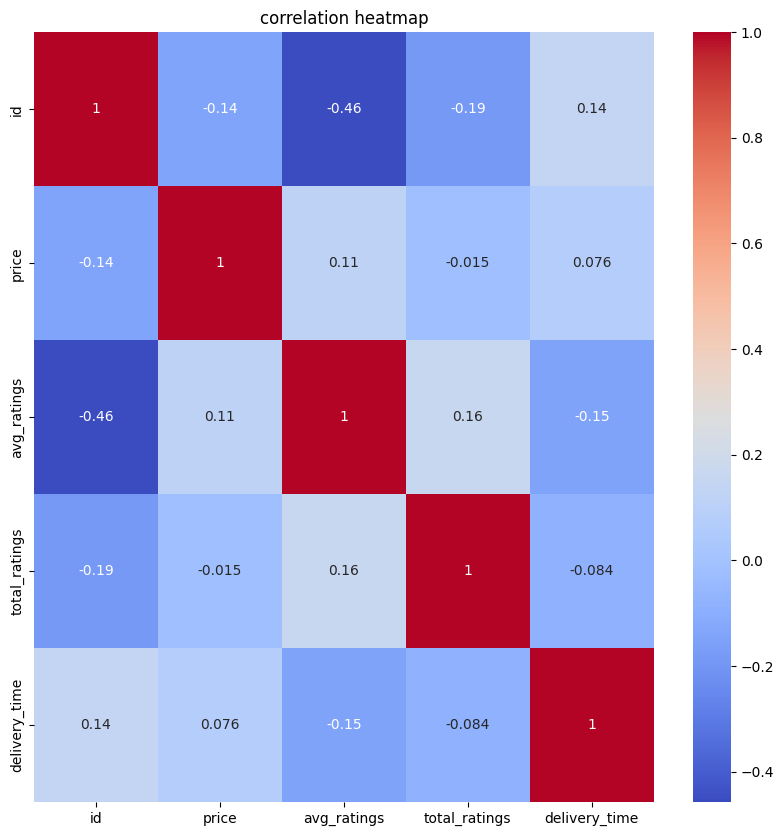

In [20]:
numeric_cols = df.select_dtypes(np.number)
plt.figure(figsize=(10,10))
sns.heatmap(numeric_cols.corr() , annot=True , cmap="coolwarm")
plt.title("correlation heatmap")
plt.show()

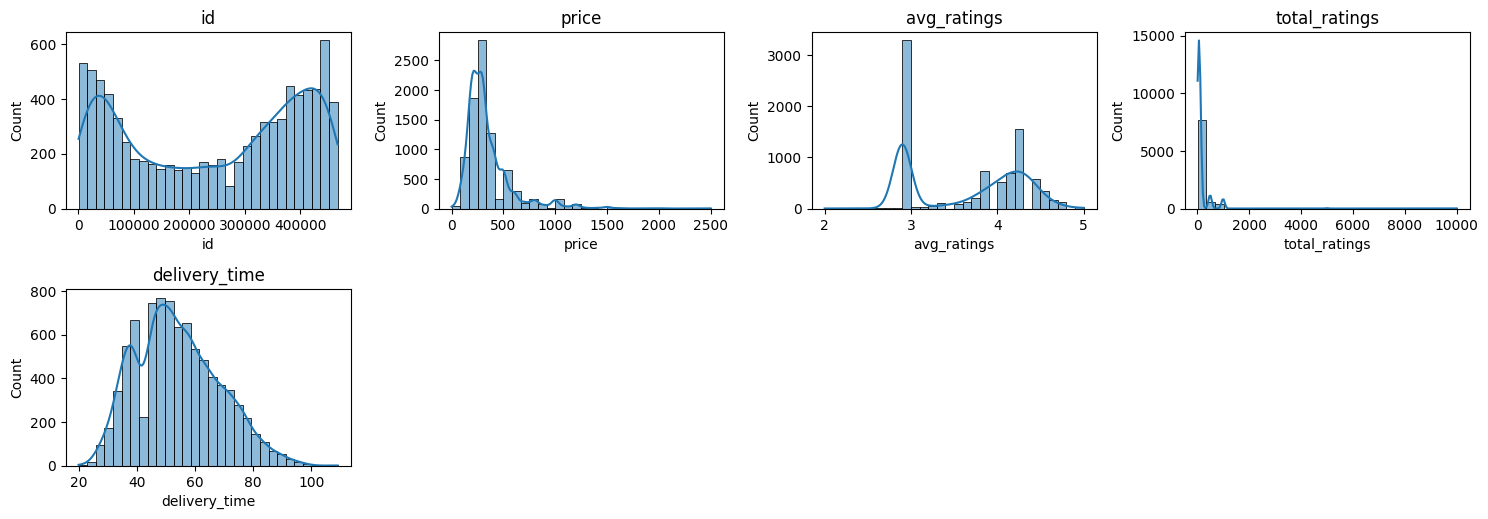

In [ ]:
# distribution plot for numerical columns
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) # adjust the number of rows and columns as needed
    sns.histplot(df[col], kde=True , bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

In [26]:
df.columns

Index(['id', 'area', 'city', 'restaurant', 'price', 'avg_ratings',
       'total_ratings', 'food_type', 'address', 'delivery_time'],
      dtype='object')

In [14]:
print(f"Zero price records: {(df['price'] == 0).sum()}")

Zero price records: 5


In [15]:
# remove 0 price record
df = df[df['price'] != 0].copy()
print(f"Zero price records after cleaning: {(df['price'] == 0).sum()}")
print(f"New dataset shape: {df.shape}")

Zero price records after cleaning: 0
New dataset shape: (8675, 10)


In [26]:
df['price_segment'] = pd.cut(df['price'], 
    bins=[0, 200, 400, 700, 2500],
    labels=['Budget', 'Mid-range', 'Premium', 'Luxury'])

* KPI

In [22]:
total_restuarants = df['restaurant'].nunique()
print(f"total restuarants : {total_restuarants}")

total_cities = df['city'].nunique() 
print(f"total cities : {total_cities}")

avg_rate = df['avg_ratings'].mean()
print(f"avg ratings : {avg_rate:,.1f}")

avg_delivery_time = df['delivery_time'].mean()
print(f"avg delivery time : {avg_delivery_time:,.1f}")

avg_price = df['price'].mean()
print(f"avg price : {avg_price:,.1f}")

total restuarants : 7861
total cities : 9
avg ratings : 3.7
avg delivery time : 54.0
avg price : 348.6


# chart visulization

* city wise avg delivery time

,avg_delivery
city,
Kolkata,67.81
Chennai,58.96
Pune,55.85
Delhi,50.73
Bangalore,50.53
Hyderabad,49.93
Surat,48.49
Mumbai,48.32
Ahmedabad,44.71


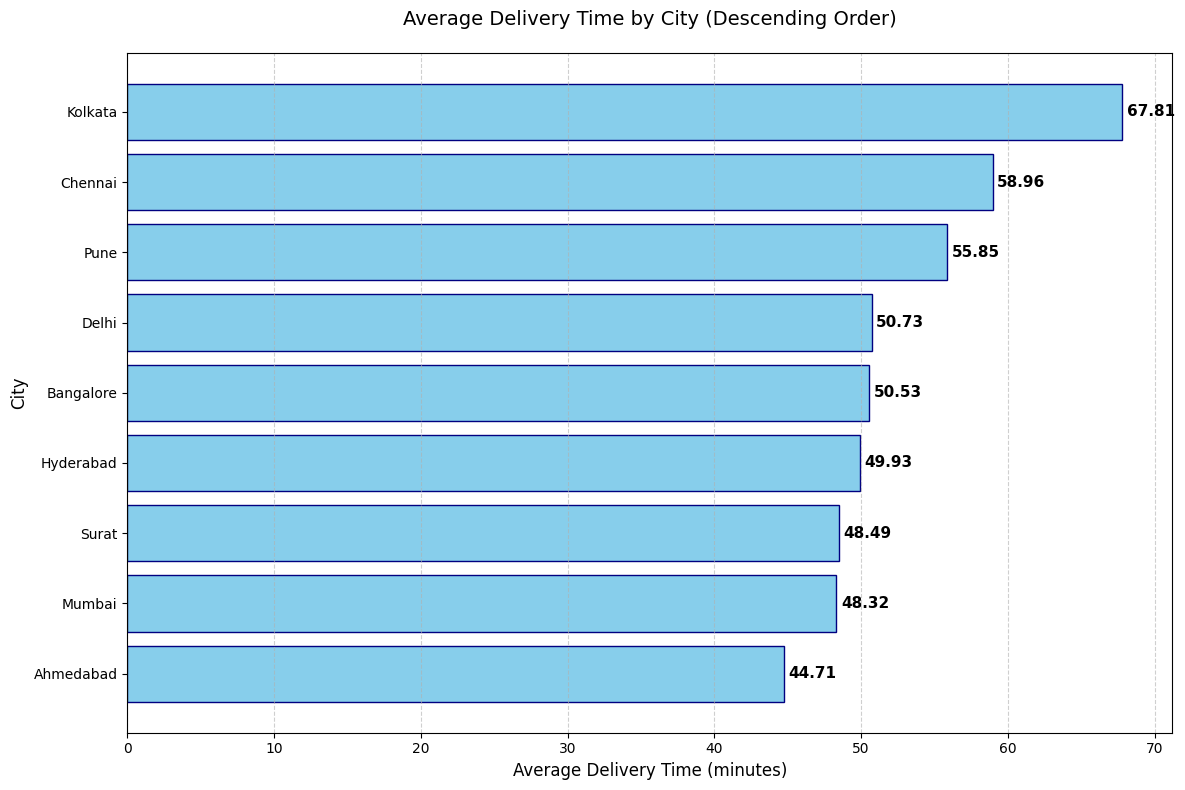

In [17]:
city_distribution = df.groupby('city').agg(
    avg_delivery = ('delivery_time' , 'mean')
).round(2)
display(city_distribution.sort_values(by='avg_delivery' , ascending=False))

plt.figure(figsize=(12, 8))
city_distribution_sorted = city_distribution.sort_values(by='avg_delivery', ascending=False)
bars = plt.barh(city_distribution_sorted.index, 
                city_distribution_sorted['avg_delivery'], 
                color='skyblue', 
                edgecolor='navy')

# Add proper data labels on each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.3, 
             bar.get_y() + bar.get_height()/2, 
             f'{width}', 
             va='center', 
             ha='left', 
             fontsize=11, 
             fontweight='bold')

# Formatting
plt.xlabel('Average Delivery Time (minutes)', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.title('Average Delivery Time by City (Descending Order)', fontsize=14, pad=20)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Highest delivery time at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

* highest avg rated restuarants(top 10)

,avg_rate
restaurant,
New Kalpana Mistanna Bhander,4.7
Corner House Ice Cream,4.7
Mithai,4.7
Chennai Square,4.6
Mithai Mandir,4.6
Maharani,4.6
Deliciae By Bunty Mahajan,4.6
Maharaj,4.5
Thaligai,4.5


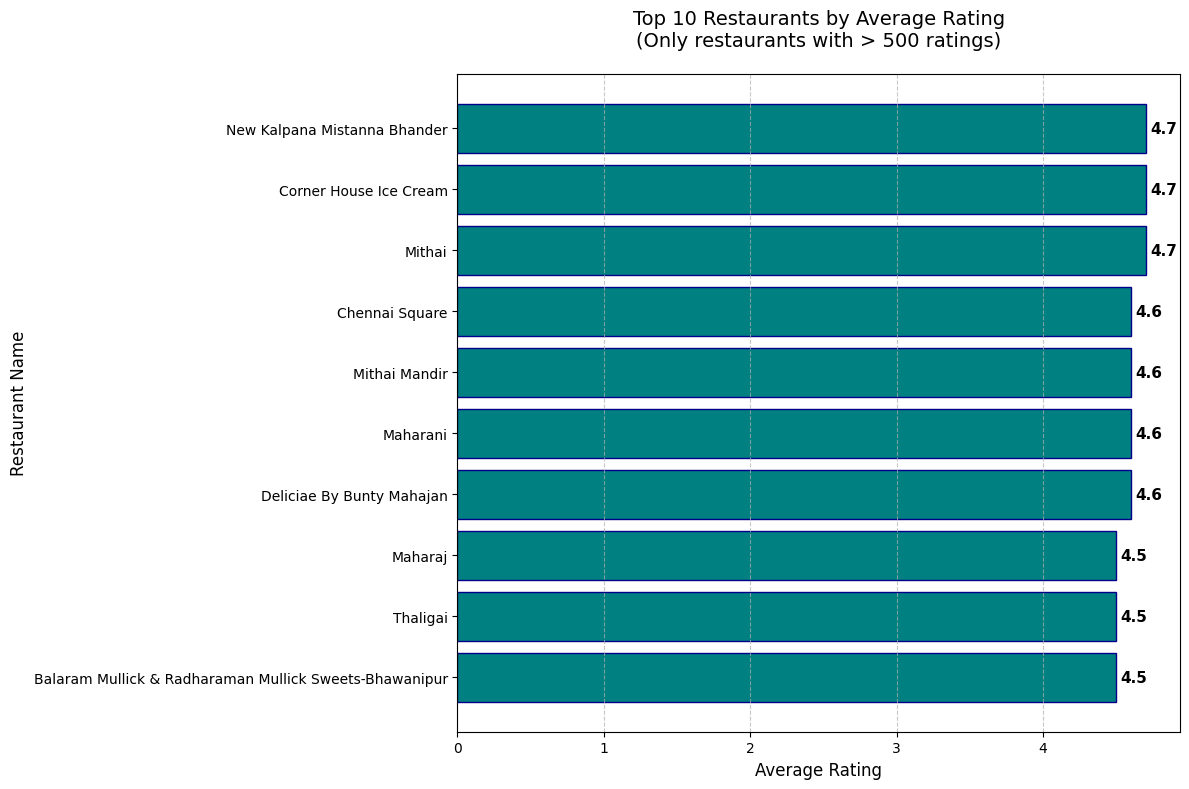

In [72]:
high_rate = df[df['total_ratings'] > 500]
avg_rating = high_rate.groupby('restaurant').agg(
    avg_rate = ('avg_ratings' , 'mean')
).round(2)
display(avg_rating.sort_values(by='avg_rate', ascending=False).head(10))

# Prepare the data (Top 10 restaurants)
top_10 = avg_rating.sort_values(by='avg_rate', ascending=False).head(10)

# Create Horizontal Bar Chart
plt.figure(figsize=(12, 8))

bars = plt.barh(top_10.index, 
                top_10['avg_rate'], 
                color='teal', 
                edgecolor='darkblue')

# Add data labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.03, 
             bar.get_y() + bar.get_height()/2, 
             f'{width}', 
             va='center', 
             ha='left', 
             fontsize=11, 
             fontweight='bold')

# Formatting
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Restaurant Name', fontsize=12)
plt.title('Top 10 Restaurants by Average Rating\n(Only restaurants with > 500 ratings)', 
          fontsize=14, pad=20)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis()   # Highest rating at the top

plt.tight_layout()
plt.show()

* Area wise avg delivery time

,avg_delivery_time
area,
Rabindrapally,97.00
Santoshpur,92.00
Haltu,91.00
Tollygunge,90.70
Smarpally Kestopur,90.00
Behala,89.75
Baguihati,88.40
Near Lal Gate Ramlal Bazarsapuipara,88.00
Baguiati,87.50


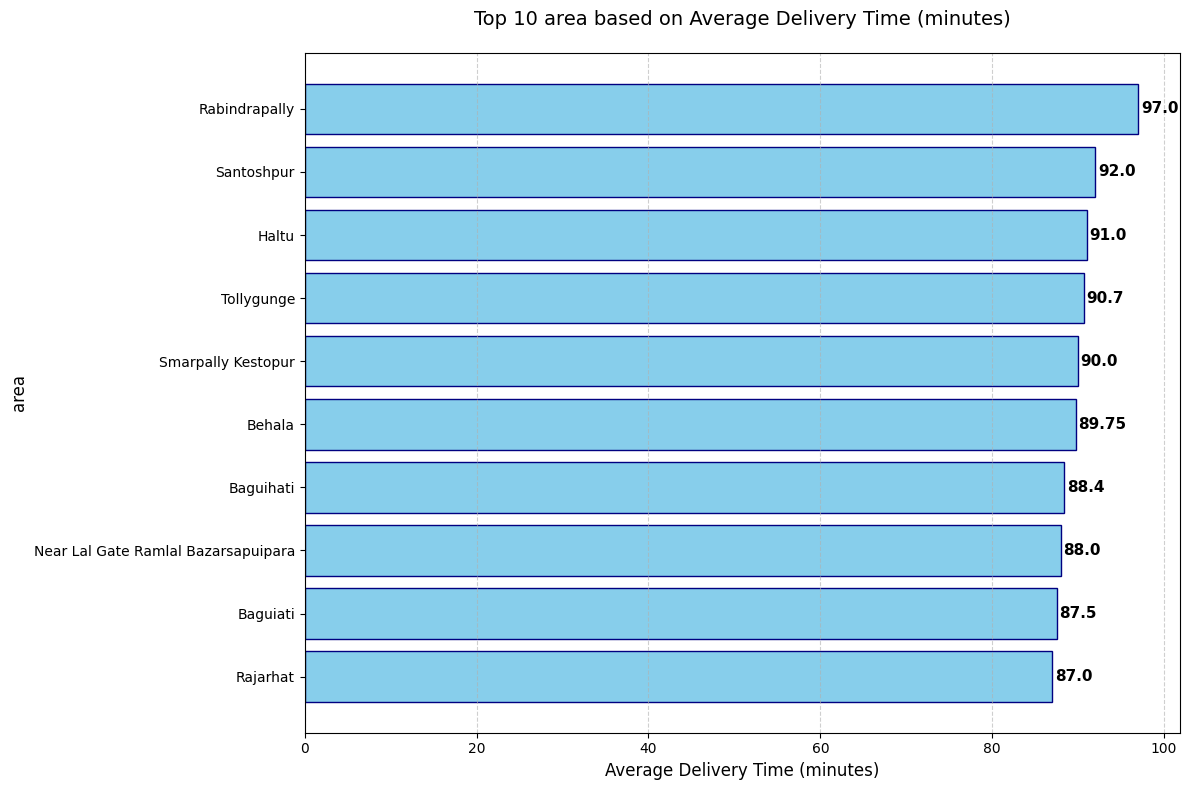

In [12]:
area = df.groupby('area').agg(
    avg_delivery_time = ('delivery_time' , 'mean')
)
display(area.sort_values(by='avg_delivery_time',ascending=False).head(10))

plt.figure(figsize=(12, 8))
area_sorted = area.sort_values(by='avg_delivery_time', ascending=False).head(10)
bars = plt.barh(area_sorted.index, 
                area_sorted['avg_delivery_time'], 
                color='skyblue', 
                edgecolor='navy')

# Add proper data labels on each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.3, 
             bar.get_y() + bar.get_height()/2, 
             f'{width}', 
             va='center', 
             ha='left', 
             fontsize=11, 
             fontweight='bold')

# Formatting
plt.xlabel('Average Delivery Time (minutes)', fontsize=12)
plt.ylabel('area', fontsize=12)
plt.title('Top 10 area based on Average Delivery Time (minutes)', fontsize=14, pad=20)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Highest delivery time at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

* do premium restaurants deliver faster?

C:\Users\Admin\AppData\Local\Temp\ipykernel_932\4243046912.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  restuarant_delivery = df.groupby('price_segment').agg(


,avg_delivery_time
price_segment,
Luxury,58.15
Premium,54.13
Mid-range,53.84
Budget,53.21


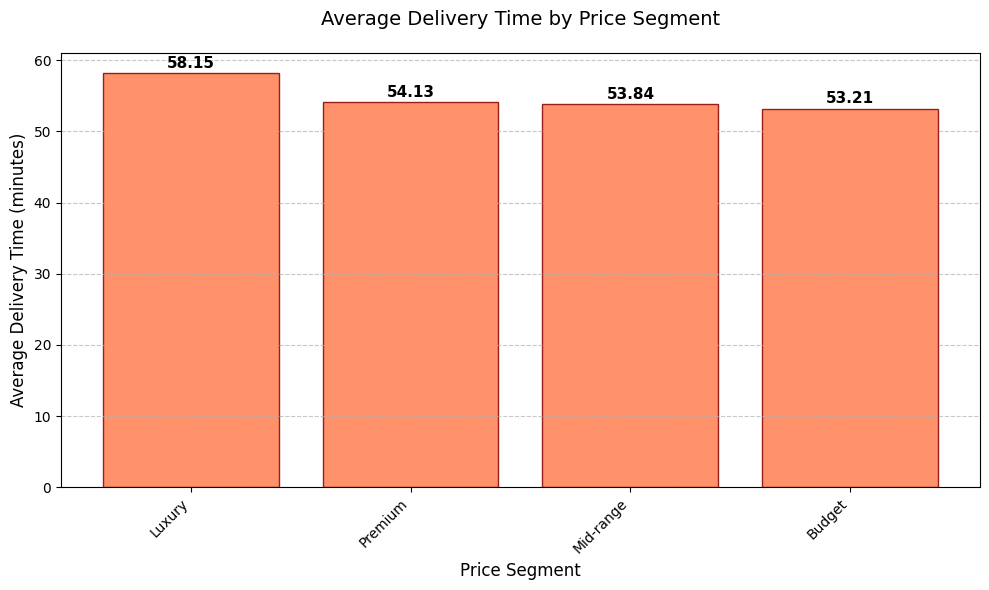

In [53]:
restuarant_delivery = df.groupby('price_segment').agg(
    avg_delivery_time = ('delivery_time' , 'mean')
).round(2)
display(restuarant_delivery.sort_values(by='avg_delivery_time',ascending=False))
restuarant_delivery_sorted = restuarant_delivery.sort_values(by='avg_delivery_time', ascending=False)

# Create Vertical Bar Chart
plt.figure(figsize=(10, 6))

bars = plt.bar(restuarant_delivery_sorted.index, 
               restuarant_delivery_sorted['avg_delivery_time'], 
               color='coral', 
               edgecolor='darkred', 
               alpha=0.85)

# Add proper data labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, 
             height + 0.3, 
             f'{height}', 
             ha='center', 
             va='bottom', 
             fontsize=11, 
             fontweight='bold')

# Chart formatting
plt.xlabel('Price Segment', fontsize=12)
plt.ylabel('Average Delivery Time (minutes)', fontsize=12)
plt.title('Average Delivery Time by Price Segment', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


* food type analysis

In [41]:
# Split the comma-separated string → then explode into individual rows
df_food = df.assign(food_type=df['food_type'].str.split(',')).explode('food_type')

# Remove extra spaces like " Chinese" → "Chinese"
df_food['food_type'] = df_food['food_type'].str.strip()

print(df_food['food_type'].value_counts().head(15))
print(f"\nTotal unique cuisines: {df_food['food_type'].nunique()}")

food_type
Chinese         2586
North Indian    1921
Indian          1771
Fast Food       1549
Beverages       1524
Desserts        1435
Biryani         1079
Snacks          1013
South Indian     856
Continental      685
Italian          591
Pizzas           587
Combo            509
Bakery           450
Tandoor          427
Name: count, dtype: int64

Total unique cuisines: 600


In [45]:
cuisine_stats = df_food.groupby('food_type').agg(
    avg_rating   = ('avg_ratings', 'mean'),
    avg_price    = ('price', 'mean'),
    avg_delivery = ('delivery_time', 'mean'),
    count        = ('restaurant', 'count')
).round(2)

# Only cuisines with 100+ entries — removes noise from rare ones
cuisine_stats = cuisine_stats[cuisine_stats['count'] >= 100]
display(cuisine_stats)

,avg_rating,avg_price,avg_delivery,count
food_type,,,,
American,3.88,441.55,54.11,297
Arabian,3.69,355.06,53.73,150
Asian,3.91,596.41,57.28,227
Bakery,3.69,327.95,51.27,450
Bengali,3.81,357.13,63.90,120
Beverages,3.66,306.32,52.60,1524
Biryani,3.67,376.34,54.41,1079
Chaat,3.77,225.21,52.11,152
Chinese,3.65,375.97,55.00,2586


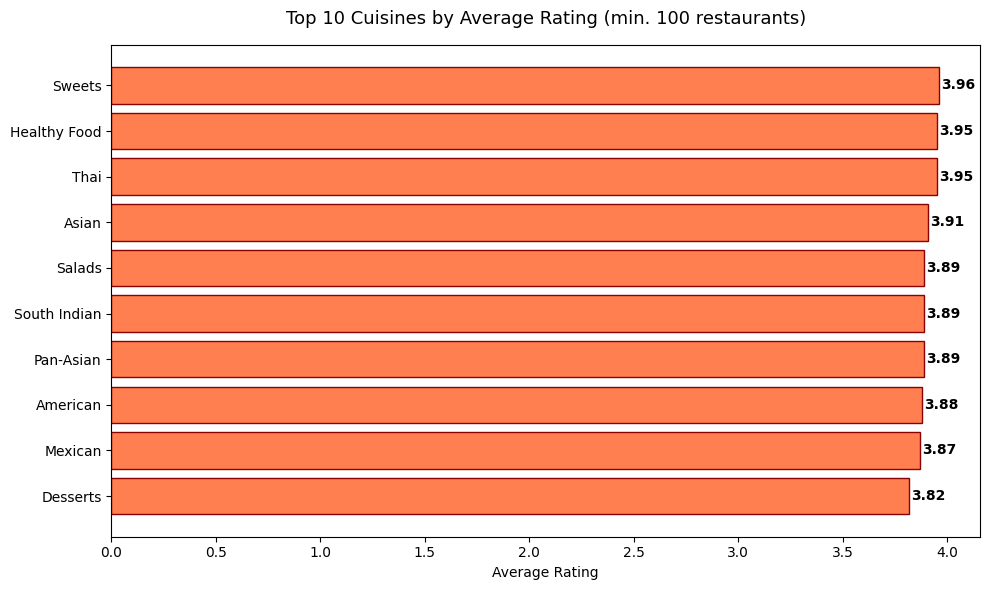

In [51]:
top_cuisines = cuisine_stats.sort_values('avg_rating', ascending=False).head(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(top_cuisines.index, top_cuisines['avg_rating'], color='coral', edgecolor='darkred')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2,
             f'{width}', va='center', fontsize=10, fontweight='bold')

plt.xlabel('Average Rating')
plt.title('Top 10 Cuisines by Average Rating (min. 100 restaurants)', fontsize=13, pad=15)
plt.gca().invert_yaxis()
# plt.xlim(3.5, 4.2)
plt.tight_layout()
plt.show()